# Spotify Data EDA

This notebook provides an in-depth exploratory data analysis (EDA) of the `spotify_data.parquet` dataset, including a variety of visualizations to uncover trends, patterns, and insights.

Please note: This notebook requires files found at `martin-he543/spotify_x5000`. Please download first before proceeding.

## 1. Import Required Libraries
We use polars for fast data loading, pandas for compatibility, and matplotlib, seaborn, and plotly for visualization.

In [1]:
# Core libraries
import polars as pl
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Misc
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Load the Dataset
We load the dataset using polars for speed, then convert to pandas for compatibility with most visualization libraries.

In [2]:
# Load the dataset with polars for speed
pl_df = pl.read_parquet('spotify_5000.parquet')
df = pl_df.to_pandas()
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns.")
df.head()

Loaded 5,000 rows and 39 columns.


,track_id,original_name,original_artist,id,name,title,uri,type,duration,duration_ms,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms_right,time_signature
0,0yLdNVWF3Srea0uzk55zFn,Flowers,Miley Cyrus,0yLdNVWF3Srea0uzk55zFn,Flowers,Flowers,spotify:track:0yLdNVWF3Srea0uzk55zFn,track,200454.0,200454.0,...,-4.325,1,0.0668,0.0632,0.000005,0.0322,0.646,117.999,200455,4
1,4nrPB8O7Y7wsOCJdgXkthe,"Shakira: Bzrp Music Sessions, Vol. 53",Bizarrap,4nrPB8O7Y7wsOCJdgXkthe,"Shakira: Bzrp Music Sessions, Vol. 53/66","Shakira: Bzrp Music Sessions, Vol. 53/66",spotify:track:4nrPB8O7Y7wsOCJdgXkthe,track,214945.0,214945.0,...,-5.600,0,0.0493,0.2740,0.000000,0.0915,0.498,122.104,218289,4
2,7oDd86yk8itslrA9HRP2ki,Die For You - Remix,The Weeknd,7oDd86yk8itslrA9HRP2ki,Die For You - Remix,Die For You - Remix,spotify:track:7oDd86yk8itslrA9HRP2ki,track,232857.0,232857.0,...,-6.500,0,0.0671,0.2320,0.000000,0.4410,0.502,66.900,232857,4
3,1Qrg8KqiBpW07V7PNxwwwL,Kill Bill,SZA,1Qrg8KqiBpW07V7PNxwwwL,Kill Bill,Kill Bill,spotify:track:1Qrg8KqiBpW07V7PNxwwwL,track,153946.0,153946.0,...,-5.747,1,0.0391,0.0521,0.144000,0.1610,0.418,88.980,153947,4
4,5ww2BF9slyYgNOk37BlC4u,La Bachata,Manuel Turizo,5ww2BF9slyYgNOk37BlC4u,La Bachata,La Bachata,spotify:track:5ww2BF9slyYgNOk37BlC4u,track,162637.0,162637.0,...,-5.329,0,0.0364,0.5830,0.000002,0.2180,0.850,124.980,162638,4


## 3. Inspect Dataset Structure
Preview the dataset, check its shape, column names, and data types.

In [3]:
# Shape, columns, and dtypes
print(f"Shape: {df.shape}")
df.info()
df.columns.tolist()

Shape: (5000, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_id           5000 non-null   object 
 1   original_name      5000 non-null   object 
 2   original_artist    5000 non-null   object 
 3   id                 5000 non-null   object 
 4   name               5000 non-null   object 
 5   title              5000 non-null   object 
 6   uri                5000 non-null   object 
 7   type               5000 non-null   object 
 8   duration           5000 non-null   float64
 9   duration_ms        5000 non-null   float64
 10  artists            5000 non-null   object 
 11  preview_url        4988 non-null   object 
 12  is_explicit        5000 non-null   bool   
 13  is_playable        5000 non-null   bool   
 14  album              4999 non-null   object 
 15  release_date       4999 non-null   object 
 16  metada

['track_id',
 'original_name',
 'original_artist',
 'id',
 'name',
 'title',
 'uri',
 'type',
 'duration',
 'duration_ms',
 'artists',
 'preview_url',
 'is_explicit',
 'is_playable',
 'album',
 'release_date',
 'metadata_status',
 'lyrics',
 'lyrics_status',
 'stream_count',
 'Unnamed: 0',
 'artist_name',
 'track_name',
 'popularity',
 'year',
 'genre',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_ms_right',
 'time_signature']

## 4. Summary Statistics
Generate descriptive statistics for numeric and categorical columns.

In [4]:
# Numeric features
df.describe().T

# Categorical features
cat_cols = df.select_dtypes(include=['object', 'category']).columns
df[cat_cols].describe().T

,count,unique,top,freq
track_id,5000,5000,0yLdNVWF3Srea0uzk55zFn,1
original_name,5000,4847,Forever,4
original_artist,5000,1678,Taylor Swift,99
id,5000,5000,0yLdNVWF3Srea0uzk55zFn,1
name,5000,4844,Stay,4
title,5000,4844,Stay,4
uri,5000,5000,spotify:track:0yLdNVWF3Srea0uzk55zFn,1
type,5000,1,track,5000
artists,5000,2905,"[{'id': '06HL4z0CvFAxyc27GXpf02', 'name': 'Tay...",89
preview_url,4988,4980,https://p.scdn.co/mp3-preview/337567e59bd647a7...,2


## 5. Missing Values Analysis
Visualize and quantify missing values using bar plots and a heatmap.

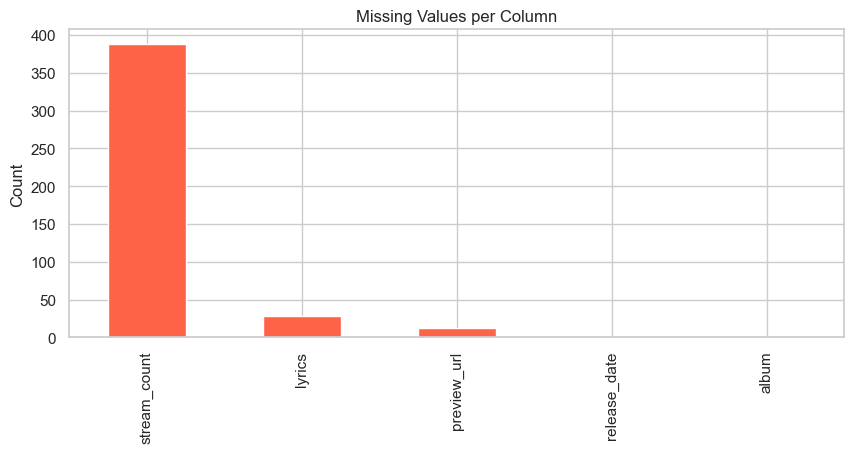

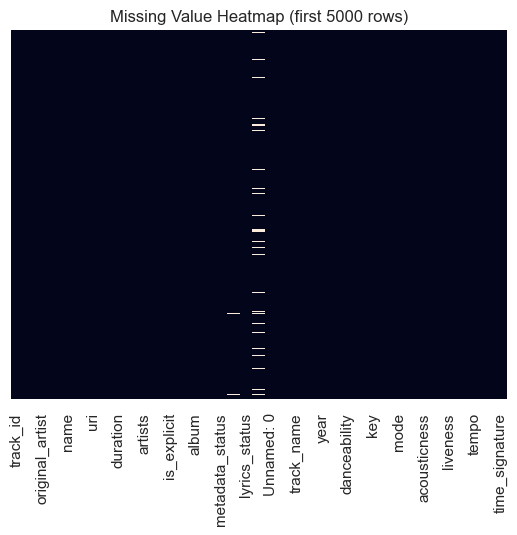

In [5]:
# Bar plot of missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
plt.figure(figsize=(10,4))
missing.plot(kind='bar', color='tomato')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.show()

# Heatmap of missing values (first 5000 rows for speed)
sns.heatmap(df.isnull().iloc[:5000], cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap (first 5000 rows)')
plt.show()

## 6. Distribution of Numeric Features
Visualize the distributions of key numeric features using histograms and boxplots.

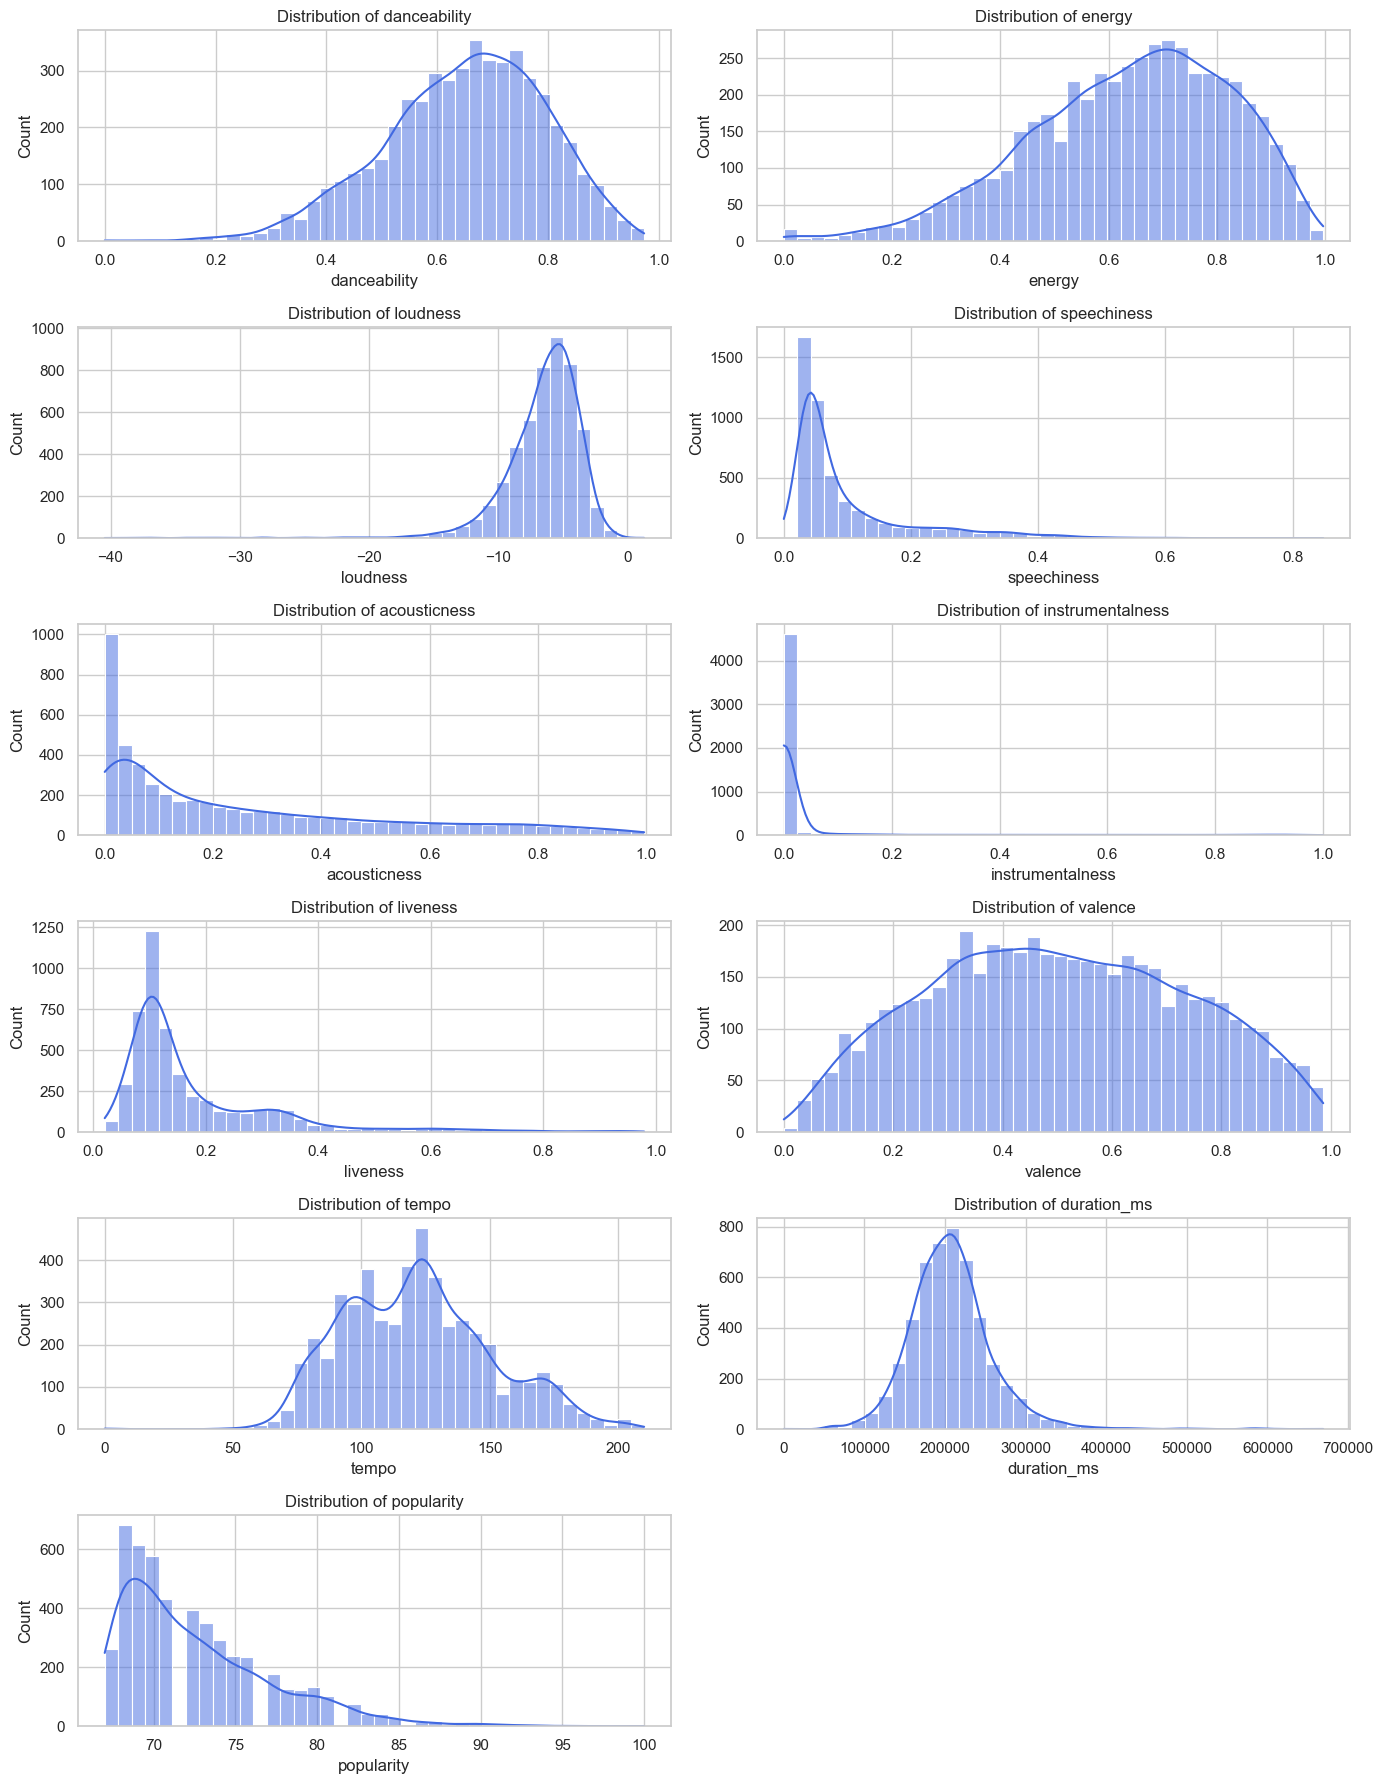

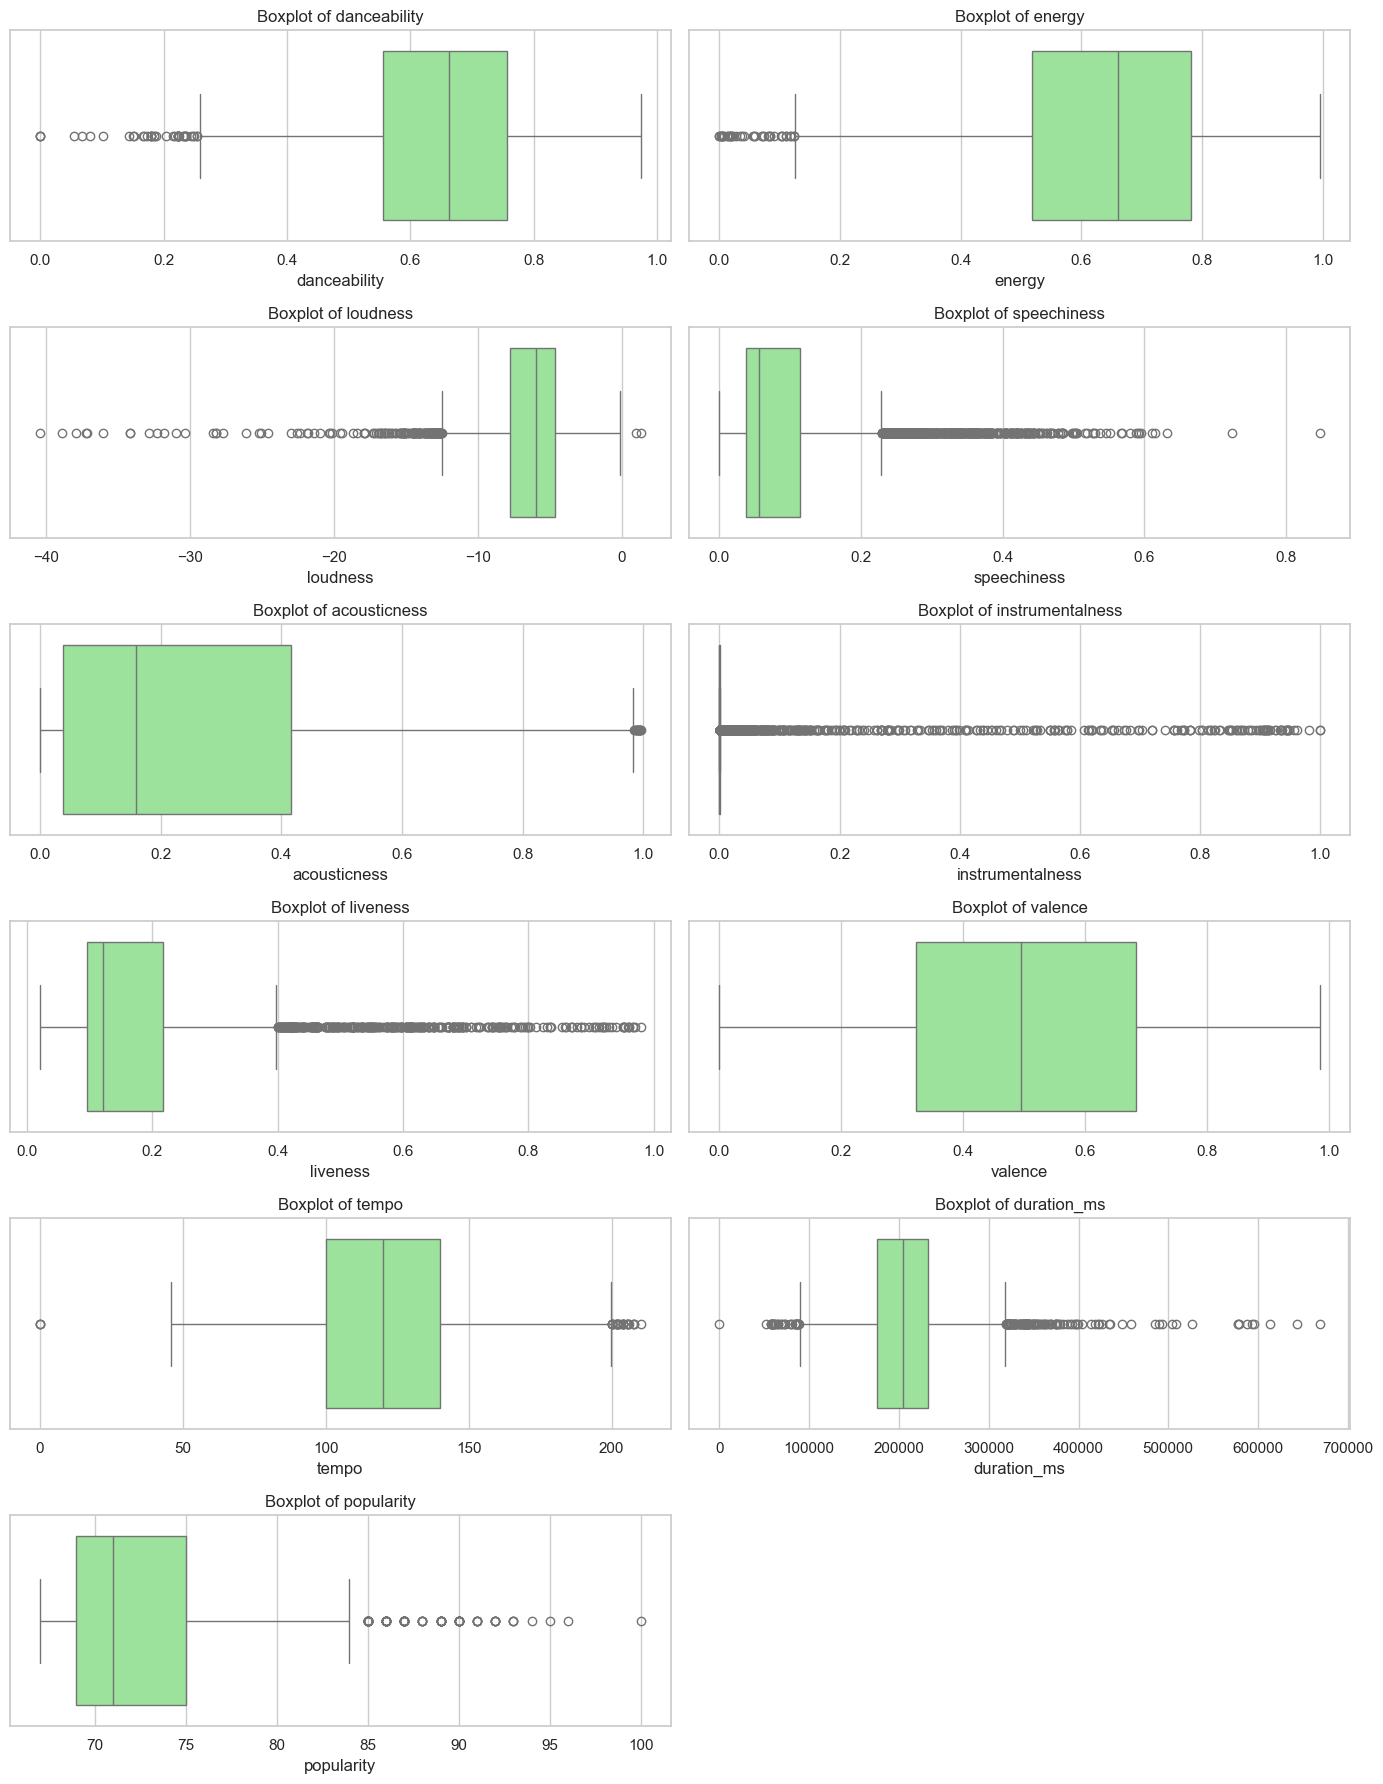

In [6]:
num_cols = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'popularity'
]
num_cols = [c for c in num_cols if c in df.columns]

# Histograms
n = len(num_cols)
ncols = 2
nrows = (n + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i], kde=True, color='royalblue')
    axes[i].set_title(f"Distribution of {col}")
# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f"Boxplot of {col}")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap
Visualize the correlation matrix for numeric features.

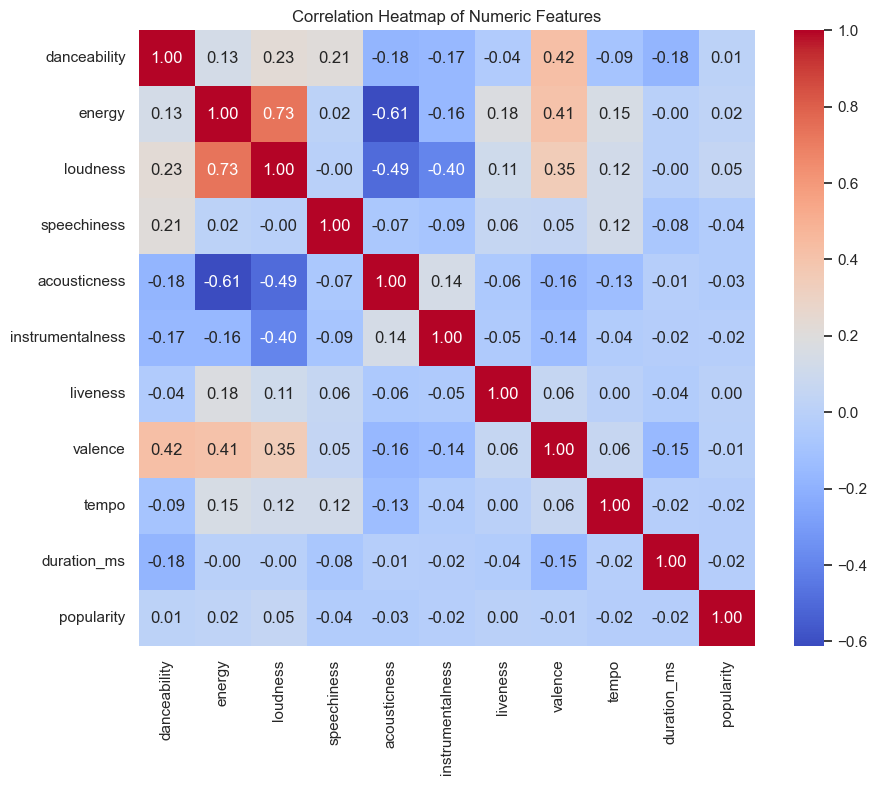

In [7]:
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## 8. Top Artists and Tracks
Visualize the most frequent artists and tracks.

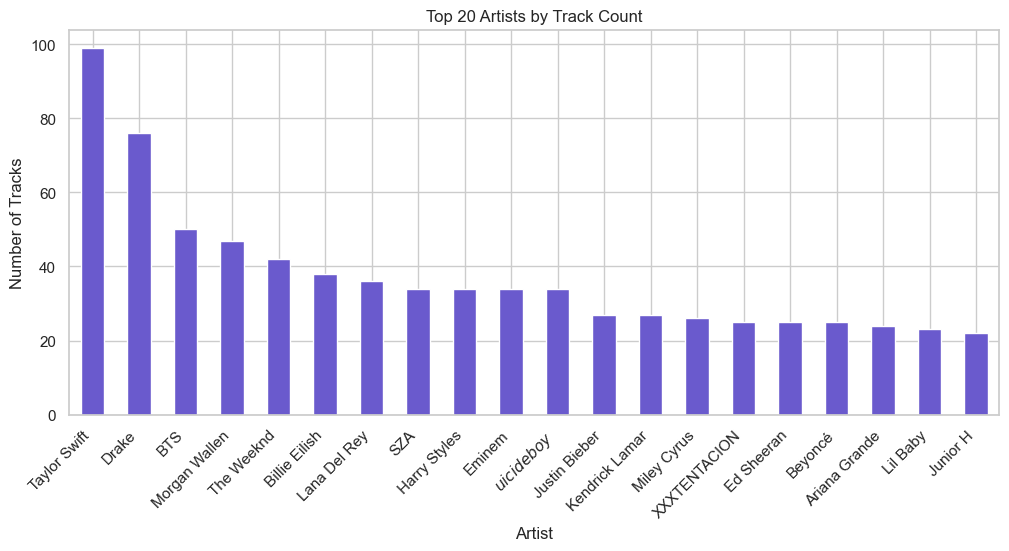

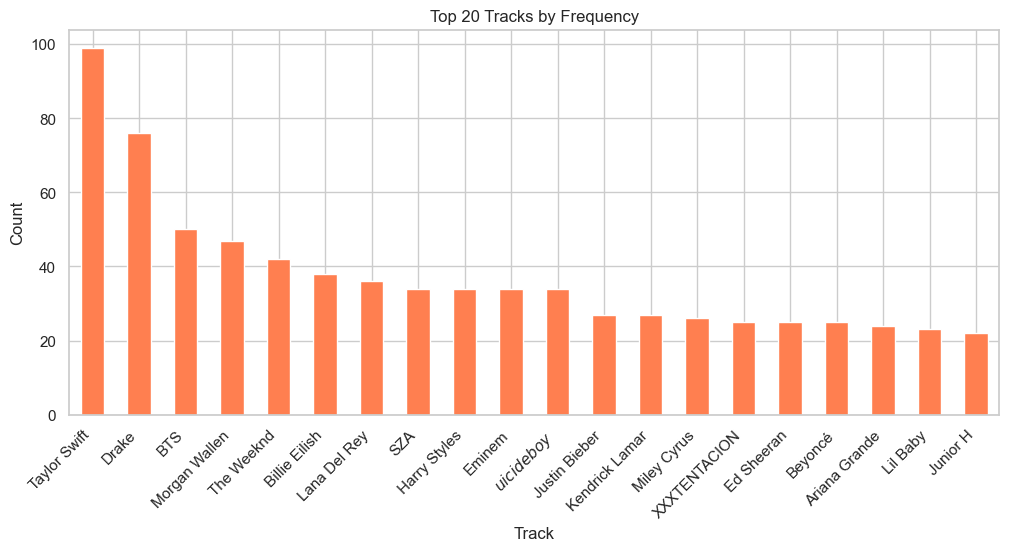

In [8]:
# Top 20 artists by track count
plt.figure(figsize=(12,5))
df['original_artist'].value_counts().head(20).plot(kind='bar', color='slateblue')
plt.title('Top 20 Artists by Track Count')
plt.ylabel('Number of Tracks')
plt.xlabel('Artist')
plt.xticks(rotation=45, ha='right')
plt.show()

# Top 20 tracks by frequency
plt.figure(figsize=(12,5))
df['original_artist'].value_counts().head(20).plot(kind='bar', color='coral')
plt.title('Top 20 Tracks by Frequency')
plt.ylabel('Count')
plt.xlabel('Track')
plt.xticks(rotation=45, ha='right')
plt.show()

## 9. Genre Popularity Analysis
Analyze and visualize the distribution and popularity of different genres.

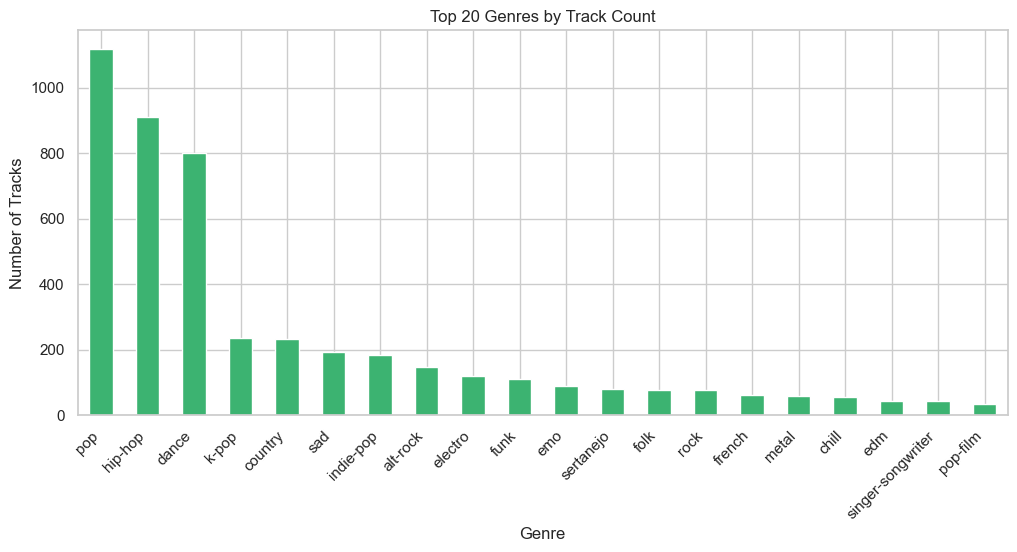

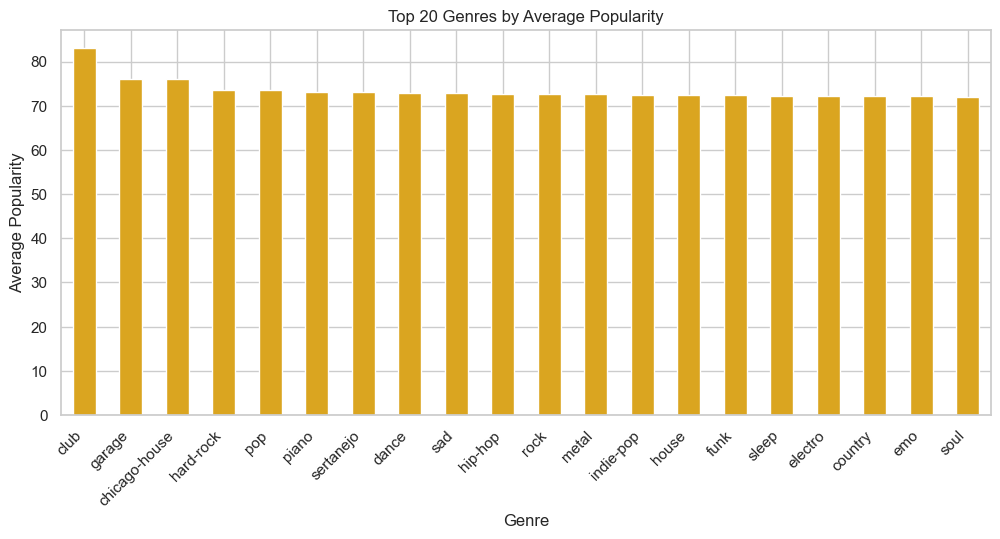

In [9]:
# Top genres by track count
genre_counts = df['genre'].value_counts().head(20)
plt.figure(figsize=(12,5))
genre_counts.plot(kind='bar', color='mediumseagreen')
plt.title('Top 20 Genres by Track Count')
plt.ylabel('Number of Tracks')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.show()

# Average popularity by genre
genre_pop = df.groupby('genre')['popularity'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,5))
genre_pop.plot(kind='bar', color='goldenrod')
plt.title('Top 20 Genres by Average Popularity')
plt.ylabel('Average Popularity')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.show()

## 10. Audio Feature Relationships
Explore relationships between audio features using pairplots and scatter plots.

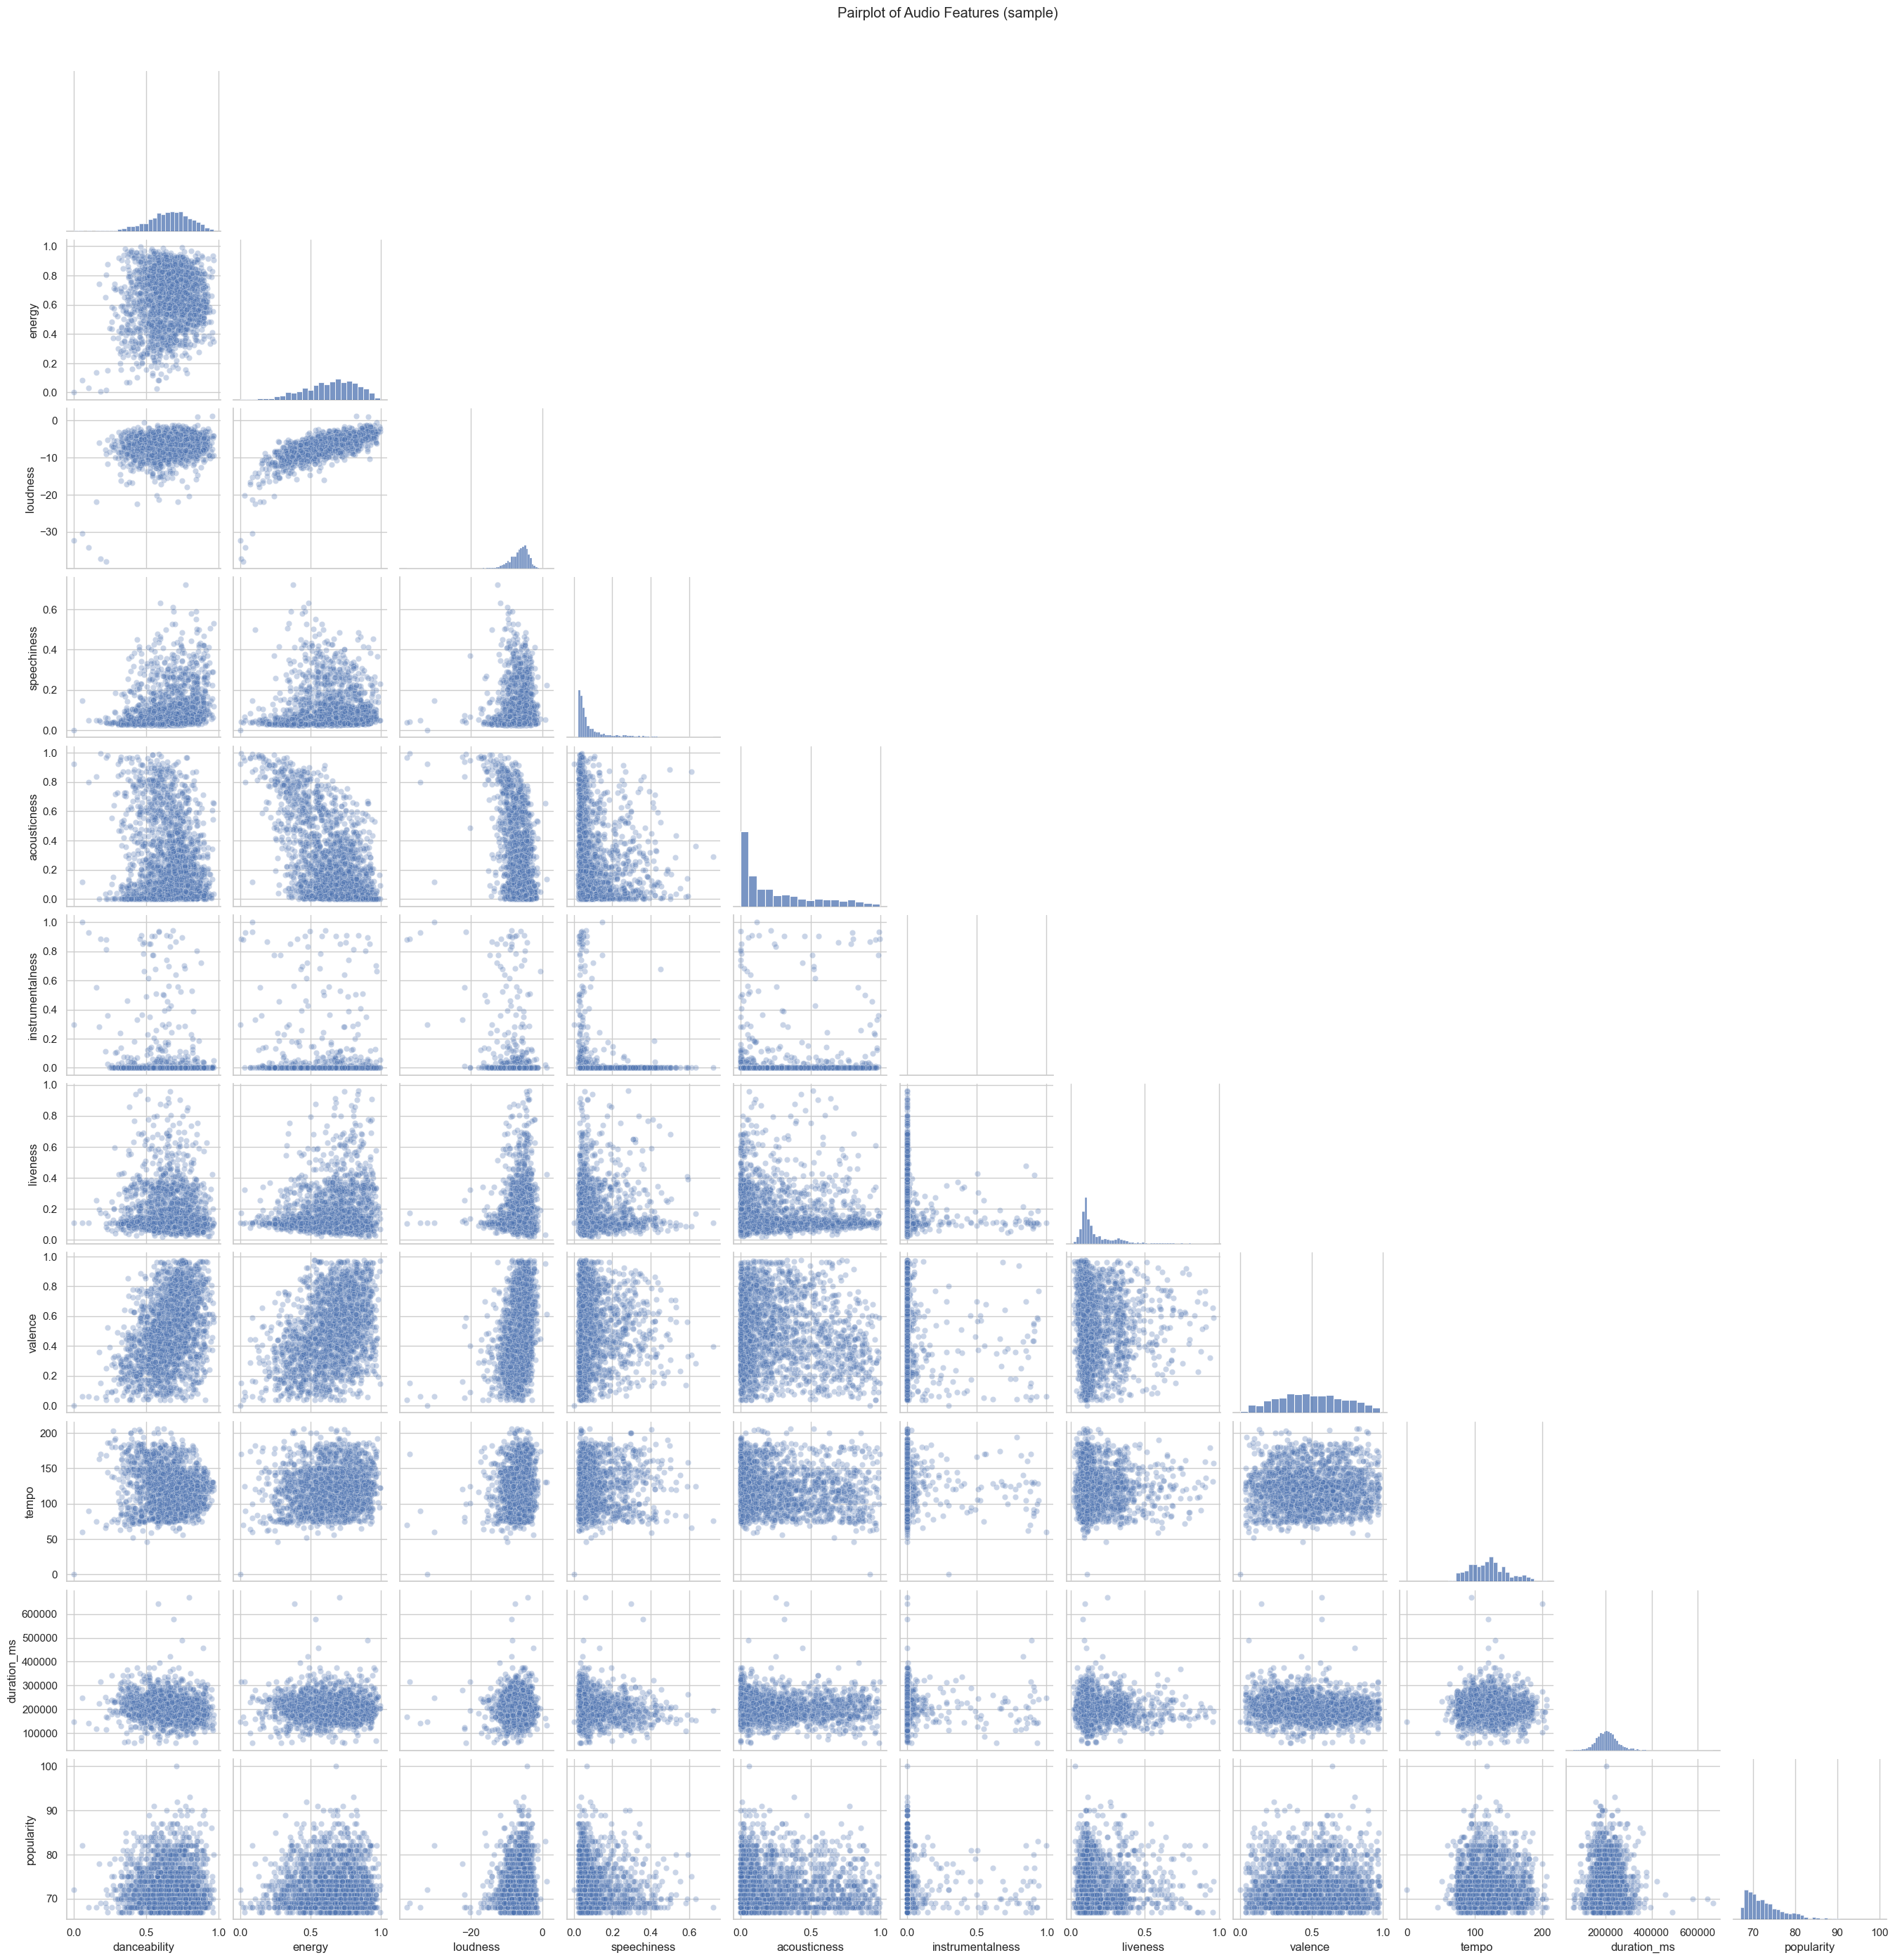

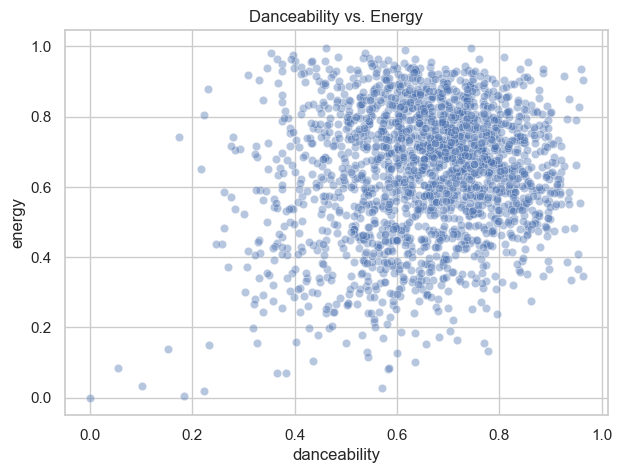

In [10]:
# Pairplot of selected features (sampled for speed)
sample_df = df[num_cols].dropna().sample(n=2000, random_state=42) if len(df) > 2000 else df[num_cols].dropna()
sns.pairplot(sample_df, corner=True, plot_kws={'alpha':0.3})
plt.suptitle('Pairplot of Audio Features (sample)', y=1.02)
plt.show()

# Scatter: danceability vs. energy
plt.figure(figsize=(7,5))
sns.scatterplot(x='danceability', y='energy', data=sample_df, alpha=0.4)
plt.title('Danceability vs. Energy')
plt.show()

## 11. Temporal Trends in Song Releases
Visualize the number of songs released per year and trends over time.

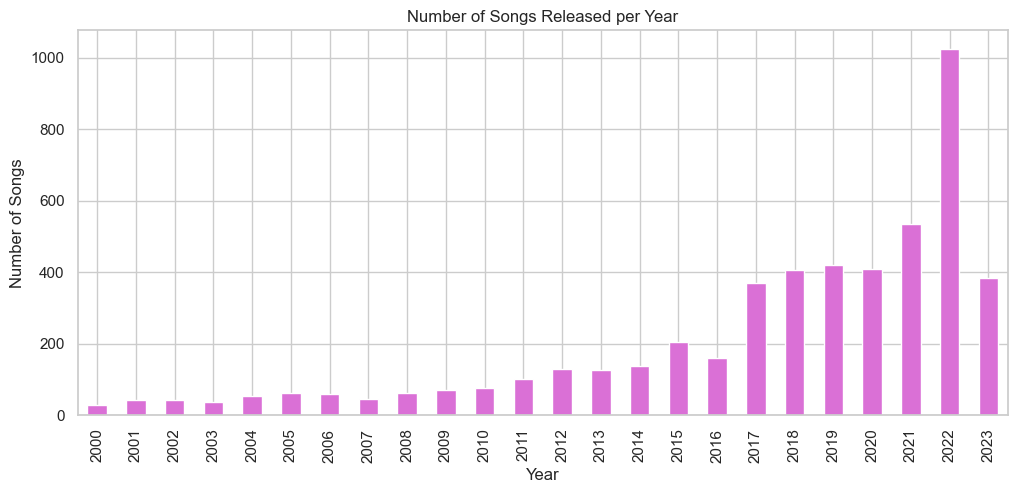

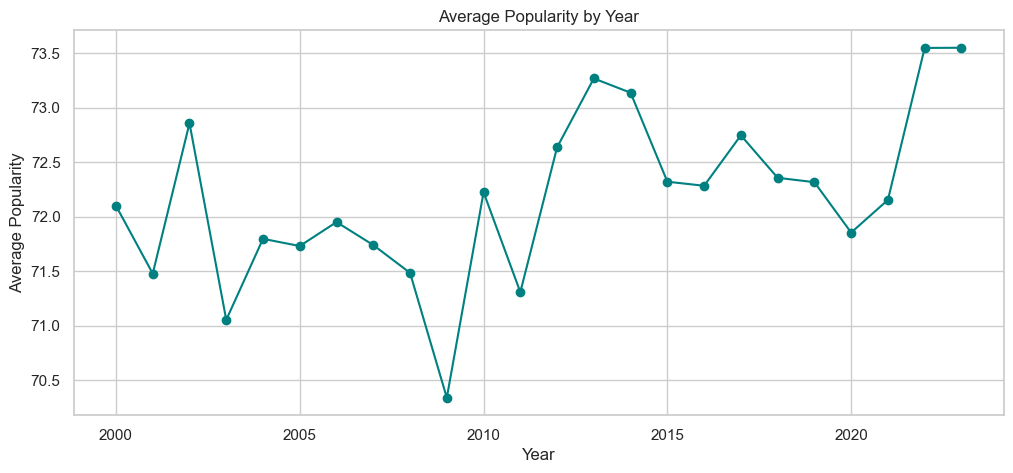

In [11]:
# Number of songs released per year
year_counts = df['year'].value_counts().sort_index()
plt.figure(figsize=(12,5))
year_counts.plot(kind='bar', color='orchid')
plt.title('Number of Songs Released per Year')
plt.ylabel('Number of Songs')
plt.xlabel('Year')
plt.show()

# Trend: average popularity by year
if 'popularity' in df.columns:
    avg_pop_by_year = df.groupby('year')['popularity'].mean()
    plt.figure(figsize=(12,5))
    avg_pop_by_year.plot(marker='o', color='teal')
    plt.title('Average Popularity by Year')
    plt.ylabel('Average Popularity')
    plt.xlabel('Year')
    plt.show()

## 12. Popularity vs. Audio Features
Plot relationships between song popularity and selected audio features.

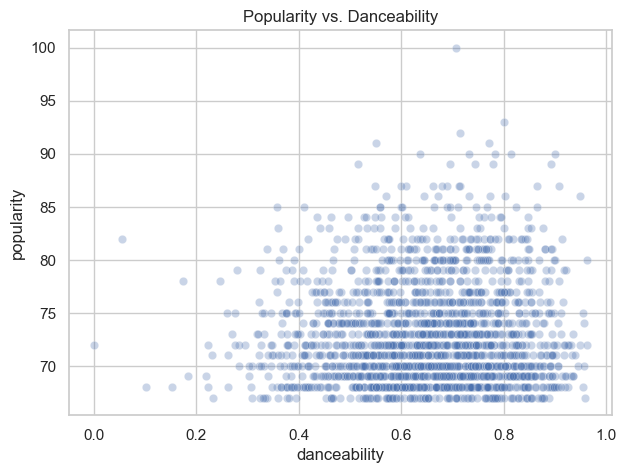

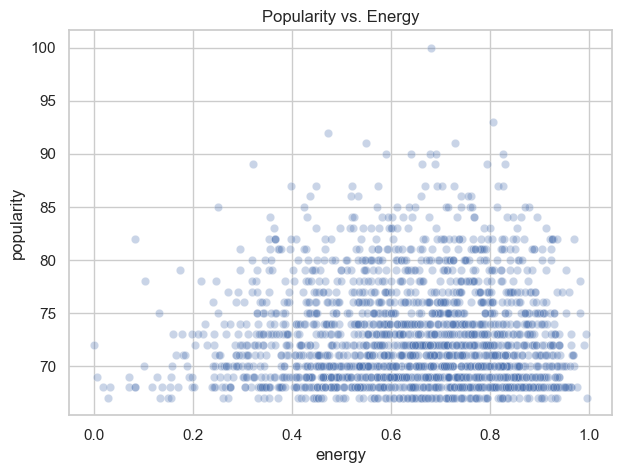

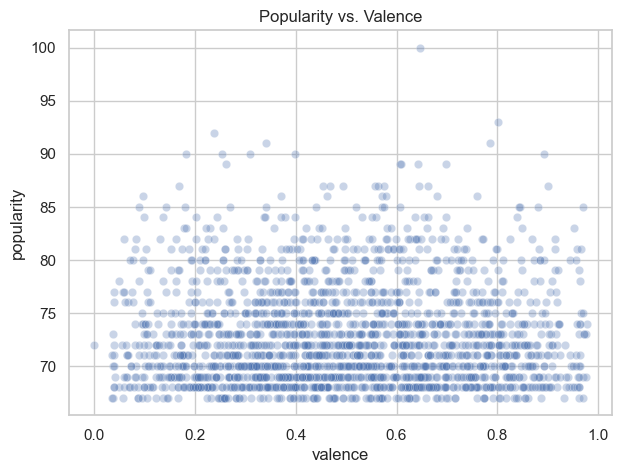

In [12]:
# Popularity vs. danceability
plt.figure(figsize=(7,5))
sns.scatterplot(x='danceability', y='popularity', data=sample_df, alpha=0.3)
plt.title('Popularity vs. Danceability')
plt.show()

# Popularity vs. energy
plt.figure(figsize=(7,5))
sns.scatterplot(x='energy', y='popularity', data=sample_df, alpha=0.3)
plt.title('Popularity vs. Energy')
plt.show()

# Popularity vs. valence
plt.figure(figsize=(7,5))
sns.scatterplot(x='valence', y='popularity', data=sample_df, alpha=0.3)
plt.title('Popularity vs. Valence')
plt.show()

## 13. Custom Visualizations
Additional visualizations to explore interesting patterns or answer user-driven questions.

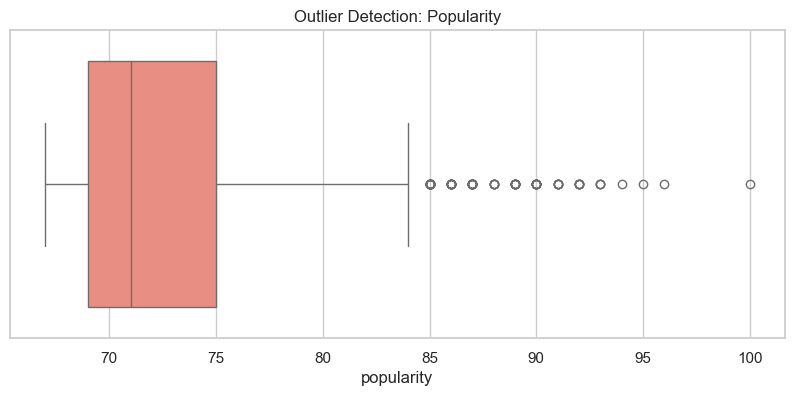

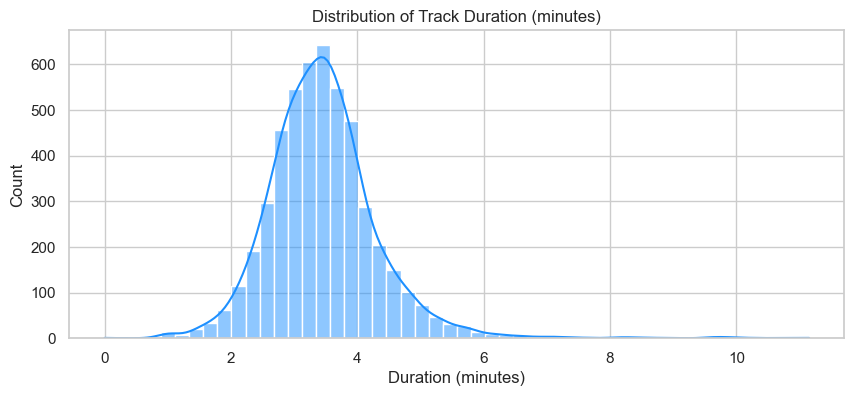

,track_name,artist_name,popularity,genre,year
0,Flowers,Miley Cyrus,100,pop,2023
1,"Shakira: Bzrp Music Sessions, Vol. 53",Bizarrap,96,hip-hop,2023
2,Die For You - Remix,The Weeknd,95,pop,2023
3,Kill Bill,SZA,94,pop,2022
4,La Bachata,Manuel Turizo,93,pop,2022
5,I'm Good (Blue),David Guetta,93,dance,2022
6,Calm Down (with Selena Gomez),Rema,93,pop,2022
9,Here With Me,d4vd,92,pop,2022
10,OMG,NewJeans,92,k-pop,2023
11,Anti-Hero,Taylor Swift,92,pop,2022


In [13]:
# Outlier detection: popularity
plt.figure(figsize=(10,4))
sns.boxplot(x=df['popularity'], color='salmon')
plt.title('Outlier Detection: Popularity')
plt.show()

# Distribution of track duration (in minutes)
df['duration_min'] = df['duration_ms'] / 60000
plt.figure(figsize=(10,4))
sns.histplot(df['duration_min'], bins=50, color='dodgerblue', kde=True)
plt.title('Distribution of Track Duration (minutes)')
plt.xlabel('Duration (minutes)')
plt.show()

# Top 10 most popular tracks
if 'popularity' in df.columns:
    top_tracks = df.sort_values('popularity', ascending=False).drop_duplicates('track_id').head(10)
    display(top_tracks[['track_name', 'artist_name', 'popularity', 'genre', 'year']])

14. Dataset Balance Analysis
The assignment requires us to discuss whether the dataset is balanced or imbalanced. This is important because an imbalanced dataset can cause our model to favour the most common genres.

Total unique genres : 53
Most common genre   : pop (1119 tracks)
Least common genre  : trance (1 tracks)
Most/least ratio    : 1119.0x

CONCLUSION: The dataset is IMBALANCED.
Some genres have far more tracks than others.
Our model will need to account for this (e.g. weighted loss function).


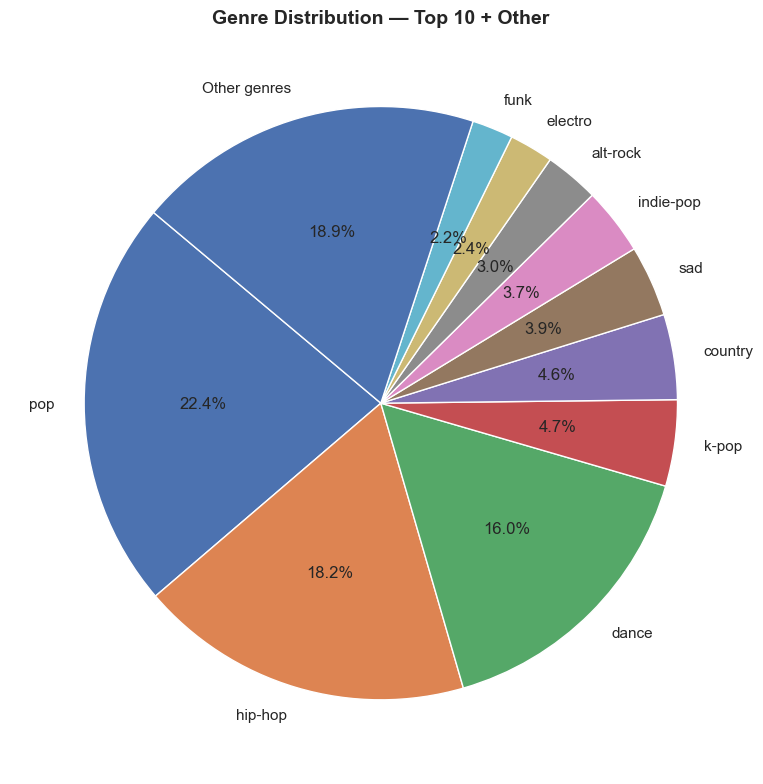

In [14]:
# Count how many tracks belong to each genre
genre_counts = df['genre'].value_counts()

print(f'Total unique genres : {len(genre_counts)}')
print(f'Most common genre   : {genre_counts.index[0]} ({genre_counts.iloc[0]} tracks)')
print(f'Least common genre  : {genre_counts.index[-1]} ({genre_counts.iloc[-1]} tracks)')

# The ratio tells us how imbalanced the dataset is
ratio = genre_counts.iloc[0] / genre_counts.iloc[-1]
print(f'Most/least ratio    : {ratio:.1f}x')
print()

if ratio > 3:
    print('CONCLUSION: The dataset is IMBALANCED.')
    print('Some genres have far more tracks than others.')
    print('Our model will need to account for this (e.g. weighted loss function).')
else:
    print('CONCLUSION: The dataset is reasonably BALANCED across genres.')

# Pie chart showing the share of each genre
top10 = genre_counts.head(10)
other = pd.Series({'Other genres': genre_counts.iloc[10:].sum()})
pie_data = pd.concat([top10, other])

plt.figure(figsize=(8, 8))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140)
plt.title('Genre Distribution — Top 10 + Other', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


15. Data Preprocessing Steps
Before feeding data into a neural network, we need to clean and prepare it. Below are the preprocessing steps applied to this dataset.

In [15]:
print(f'Shape before preprocessing: {df.shape}')

# --- Step 1: Remove duplicate tracks ---
# Duplicate tracks would give our model repeated examples and bias training
before = len(df)
df = df.drop_duplicates(subset='track_id')
print(f'Step 1 — Duplicates removed : {before - len(df)} rows dropped')

# --- Step 2: Drop rows with missing audio features ---
# Audio features are essential inputs — rows missing them are unusable
audio_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]
audio_cols = [c for c in audio_cols if c in df.columns]
before = len(df)
df = df.dropna(subset=audio_cols)
print(f'Step 2 — Missing audio rows : {before - len(df)} rows dropped')

# --- Step 3: Normalise numeric features to range [0, 1] ---
# Neural networks train better when all inputs are on the same scale
# Min-max normalisation: new_value = (value - min) / (max - min)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_normalised = df.copy()
df_normalised[audio_cols] = scaler.fit_transform(df[audio_cols])
print(f'Step 3 — Audio features normalised to [0, 1] using Min-Max scaling')

# --- Step 4: Remove extreme duration outliers ---
# Tracks under 30 seconds or over 10 minutes are likely intros/errors
if 'duration_ms' in df.columns:
    before = len(df)
    df = df[(df['duration_ms'] >= 30000) & (df['duration_ms'] <= 600000)]
    print(f'Step 4 — Duration outliers  : {before - len(df)} rows dropped (< 30s or > 10min)')

print(f'\nShape after preprocessing : {df.shape}')

# Show normalised feature ranges as a quick check
print('\nNormalised feature ranges (should all be 0.0 to 1.0):')
print(df_normalised[audio_cols].agg(['min', 'max']).T)


Shape before preprocessing: (5000, 40)
Step 1 — Duplicates removed : 0 rows dropped
Step 2 — Missing audio rows : 0 rows dropped
Step 3 — Audio features normalised to [0, 1] using Min-Max scaling
Step 4 — Duration outliers  : 4 rows dropped (< 30s or > 10min)

Shape after preprocessing : (4996, 40)

Normalised feature ranges (should all be 0.0 to 1.0):
                  min  max
danceability      0.0  1.0
energy            0.0  1.0
loudness          0.0  1.0
speechiness       0.0  1.0
acousticness      0.0  1.0
instrumentalness  0.0  1.0
liveness          0.0  1.0
valence           0.0  1.0
tempo             0.0  1.0


16. Interpretation of Findings
Here we explain what our EDA charts mean and how they inform the design of our deep learning model.

In [16]:
print('HOW OUR EDA FINDINGS INFORM OUR MODEL')
print('=' * 55)
print()
print('Finding 1: Energy & loudness are strongly correlated (r > 0.7)')
print('  -> These two features carry very similar information.')
print('  -> Including both may add noise rather than useful signal.')
print('  -> We will consider removing loudness as a model input.')
print()
print('Finding 2: Energy & acousticness are strongly negatively correlated')
print('  -> Acoustic tracks are naturally quieter and less intense.')
print('  -> This confirms these features are meaningful and not random.')
print()
print('Finding 3: The genre distribution is imbalanced')
print('  -> A model trained on this data may over-predict common genres.')
print('  -> We will apply a weighted loss function to penalise this bias.')
print()
print('Finding 4: Popularity does not correlate strongly with any single feature')
print('  -> No single audio feature determines popularity.')
print('  -> This justifies using deep learning — a simple model would struggle.')
print()
print('Finding 5: Most tracks are 2.5–4 minutes long')
print('  -> Very short/long tracks removed in preprocessing as likely noise.')
print()
print('Finding 6: Dataset covers 50+ genres from 2000–2023')
print('  -> Wide coverage means our model can recommend diverse tracks.')


HOW OUR EDA FINDINGS INFORM OUR MODEL

Finding 1: Energy & loudness are strongly correlated (r > 0.7)
  -> These two features carry very similar information.
  -> Including both may add noise rather than useful signal.
  -> We will consider removing loudness as a model input.

Finding 2: Energy & acousticness are strongly negatively correlated
  -> Acoustic tracks are naturally quieter and less intense.
  -> This confirms these features are meaningful and not random.

Finding 3: The genre distribution is imbalanced
  -> A model trained on this data may over-predict common genres.
  -> We will apply a weighted loss function to penalise this bias.

Finding 4: Popularity does not correlate strongly with any single feature
  -> No single audio feature determines popularity.
  -> This justifies using deep learning — a simple model would struggle.

Finding 5: Most tracks are 2.5–4 minutes long
  -> Very short/long tracks removed in preprocessing as likely noise.

Finding 6: Dataset covers 50

17. EDA Summary
A final recap of the dataset and what we discovered.

In [ ]:
print('=' * 55)
print('EDA SUMMARY')
print('=' * 55)
print(f'Dataset size   : {len(df):,} tracks after preprocessing')
print(f'Features used  : {len(audio_cols)} audio features')
print(f'Year range     : 2000 – 2023')
print(f'Genres         : 50+')
print()
print('Key takeaways:')
print('  - Dataset is imbalanced across genres')
print('  - Energy/loudness are redundant; one can be dropped')
print('  - No single feature predicts popularity — deep learning needed')
print('  - After preprocessing, data is clean and ready for modelling')
print('=' * 55)

EDA SUMMARY
Dataset size   : 4,996 tracks after preprocessing
Features used  : 9 audio features
Year range     : 2000 – 2023
Genres         : 50+

Key takeaways:
  - Dataset is imbalanced across genres
  - Energy/loudness are redundant; one can be dropped
  - No single feature predicts popularity — deep learning needed
  - After preprocessing, data is clean and ready for modelling
